In [12]:
import numpy as np, scanpy as sc

dataset_path = "/media/rohola/ssd_storage/primary/"

import os
files = []
for file in os.listdir(dataset_path)[:10]:
    files.append(sc.read_h5ad(dataset_path + file))

cells = sc.concat(files)
print(cells.shape)

(100000, 60664)


In [ ]:
cell_type_count = cells.obs.value_counts(['cell_type']).reset_index()
unique_cell_types = (cell_type_count[0] > 1000).sum()
print((cell_type_count[0] > 1000).sum())

cells = cells[cells.obs.cell_type.isin(cell_type_count[(cell_type_count[0] > 1000)]['cell_type'])]
print(cells.shape)

21
(53423, 60664)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 5, whiten=True)
pca_coordinates = pca.fit_transform(cells.X.toarray()) #50sec to run, could also select some highly variable genes to begin with

In [ ]:
# bin the expressions, to coarse grain the cell states

pca_coordinates_bin = np.digitize(pca_coordinates, bins=np.arange(-3, 3+1, step=1))
print(pca_coordinates[0], pca_coordinates_bin[0])

In [ ]:
# 511 coarse grained states map to 53k phenotypes, we use their frequencies to define phenotype probability distributions
np.unique(pca_coordinates_bin, axis=0).__len__()

511

In [37]:
cells.obs['pca_bins'] = [tuple(bin_expression) for bin_expression in pca_coordinates_bin.tolist()]
cell_states = cells.obs.value_counts(['pca_bins', 'cell_type']).reset_index()
cell_states.columns = ['pca_bins', 'cell_type', 'count']
cell_states

,pca_bins,cell_type,count
0,"(2, 5, 3, 4, 4)",L2/3-6 intratelencephalic projecting glutamate...,1516
1,"(3, 2, 2, 4, 3)",glutamatergic neuron,1196
2,"(2, 5, 3, 3, 4)",neuron,1056
3,"(4, 4, 3, 3, 4)",B cell,1029
4,"(2, 5, 3, 3, 4)",L2/3-6 intratelencephalic projecting glutamate...,947
...,...,...,...
1613,"(2, 3, 3, 4, 3)",native cell,1
1614,"(2, 3, 3, 4, 3)",oligodendrocyte,1
1615,"(2, 3, 3, 4, 4)",malignant cell,1
1616,"(2, 3, 4, 3, 3)",native cell,1


In [45]:
unique_cell_types = cell_type_count[(cell_type_count[0] > 1000)]['cell_type'].tolist()
print(unique_cell_types[:5])
unique_cell_states = cell_states['pca_bins'].unique()

new_dataset = []

for cell_state in unique_cell_states: # double for loop a bit autistic sorry
    counts = []
    for cell_type in unique_cell_types:
        count = cell_states[(cell_states.pca_bins == cell_state) & (cell_states.cell_type == cell_type)]['count']
        counts.append(count.tolist()[0] if not count.empty else 0)

    probability = np.array(counts)/np.array(counts).sum()
    new_dataset.append({"genotype": cell_state, "phenotype_probability_distribution": probability})

import pandas as pd
new_dataset = pd.DataFrame.from_dict(new_dataset)

['neuron', 'glutamatergic neuron', 'CD4-positive, alpha-beta T cell', 'L2/3-6 intratelencephalic projecting glutamatergic cortical neuron', 'CD8-positive, alpha-beta T cell']


probabilities:
[0.34754797 0.00597015 0.         0.64648188 0.        ]
[0.03877423 0.74796748 0.         0.         0.        ]
[0.52642074 0.00149551 0.         0.47208375 0.        ]
[0.         0.         0.08521601 0.         0.18826793]
[0.         0.         0.35083848 0.         0.10679612]


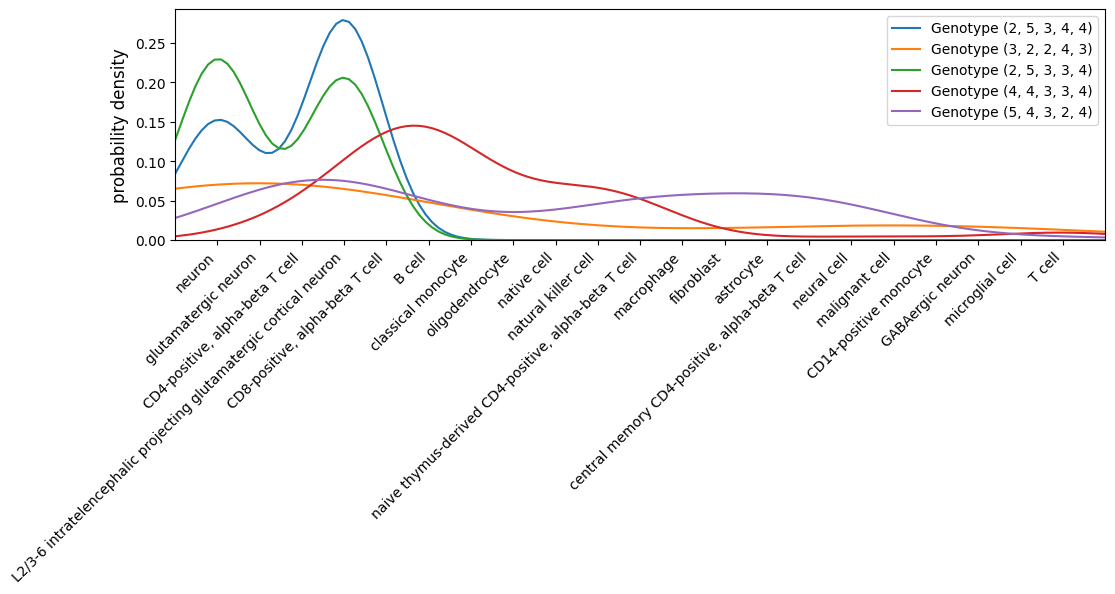

In [148]:
#new_dataset.head()
import matplotlib.pyplot as plt, seaborn as sns

fig, ax = plt.subplots(1,1, figsize=(12, 3))
print("probabilities:")
for i in range(5):
    p = np.array(new_dataset['phenotype_probability_distribution'].iloc[i])
    print(p[:5])
    sns.kdeplot(x=np.arange(len(p)), weights=p, bw_adjust=0.5, label=f"Genotype {new_dataset['genotype'].iloc[i]}", ax=ax)
    
ax.set_ylabel("probability density", fontsize=12)
ax.set_xlim(0-1, len(unique_cell_types))
ax.set_xticks(ticks=np.arange(len(unique_cell_types)), labels=unique_cell_types, rotation=45, ha="right")
ax.legend()
plt.show()